# WiDS Global Datathon 2026 - Survival Analysis EDA

W tym notatniku przeprowadzimy pogłębioną Eksploracyjną Analizę Danych (EDA) dla problemu przewidywania prawdopodobieństwa dotarcia pożaru do strefy ewakuacyjnej w określonych horyzontach czasowych (12h, 24h, 48h, 72h).

**Nasze główne cele to:**
1. Sprawdzenie podstawowych statystyk i braków danych.
2. Analiza kluczowej reguły "5km gate" – podział na pożary w strefie "Near" (<5km) oraz "Far" (>=5km).
3. Przebadanie relacji czasu do uderzenia (time-to-hit) dla cenzurowanych i niecenzurowanych zdarzeń (wpływ na funkcję przeżycia).
4. Identyfikacja najsilniejszych cech (np. prędkość zbliżania się, wskaźniki zagrożenia), które pomogą w lepszym modelowaniu.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguracja wizualna
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
sns.set_palette("muted")

# Wczytanie danych
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Rozmiar zbioru treningowego: {train_df.shape}")
print(f"Rozmiar zbioru testowego: {test_df.shape}")

Rozmiar zbioru treningowego: (221, 37)
Rozmiar zbioru testowego: (95, 35)


In [3]:
# Podstawowy przegląd danych
display(train_df.head(3))

print("\n--- Podsumowanie braków danych w zbiorze treningowym ---")
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
if len(missing_train) > 0:
    print(missing_train)
else:
    print("Brak pustych wartości (Null) w zbiorze treningowym.")

print("\n--- Podsumowanie braków danych w zbiorze testowym ---")
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
if len(missing_test) > 0:
    print(missing_test)
else:
    print("Brak pustych wartości (Null) w zbiorze testowym.")

print("\n--- Rozkład zmiennej celu (event) w zbiorze treningowym ---")
# 1 = pożar uderzył w strefę (wydarzenie miało miejsce), 0 = pożar nie uderzył / przypadek cenzurowany
print(train_df["event"].value_counts(dropna=False, normalize=True) * 100)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1



--- Podsumowanie braków danych w zbiorze treningowym ---
Brak pustych wartości (Null) w zbiorze treningowym.

--- Podsumowanie braków danych w zbiorze testowym ---
Brak pustych wartości (Null) w zbiorze testowym.

--- Rozkład zmiennej celu (event) w zbiorze treningowym ---
event
0    68.778281
1    31.221719
Name: proportion, dtype: float64


## Analiza reguły "5km Gate" (Dystans a Trafienie)

W tej sekcji przyjrzymy się kluczowej regule, która pozwala rozbić nasz model na dwie warstwy (tzw. podejście "Distance Stratified"). Główną kolumną określającą pozycję startową pożaru jest `dist_min_ci_0_5h`.

**Zasady Analizy Przeżycia dla tych danych:**
* **Event (1)**: Pożar uderzył w strefę (niezależnie czy w 12h, 24h, 48h czy 72h).
* **Ocenzurowanie (0)**: Pożar nie uderzył w strefę przez pierwsze 72 godziny (cenzurowanie prawostronne) – czyli dla modelu przetrwał bez kolizji.

Poniższy kod wygeneruje wykresy rozkładu i pudełkowe (boxplots), które bezsprzecznie udowodnią, że próg 5km drastycznie zmienia charakterystykę prawdopodobieństwa uderzenia.

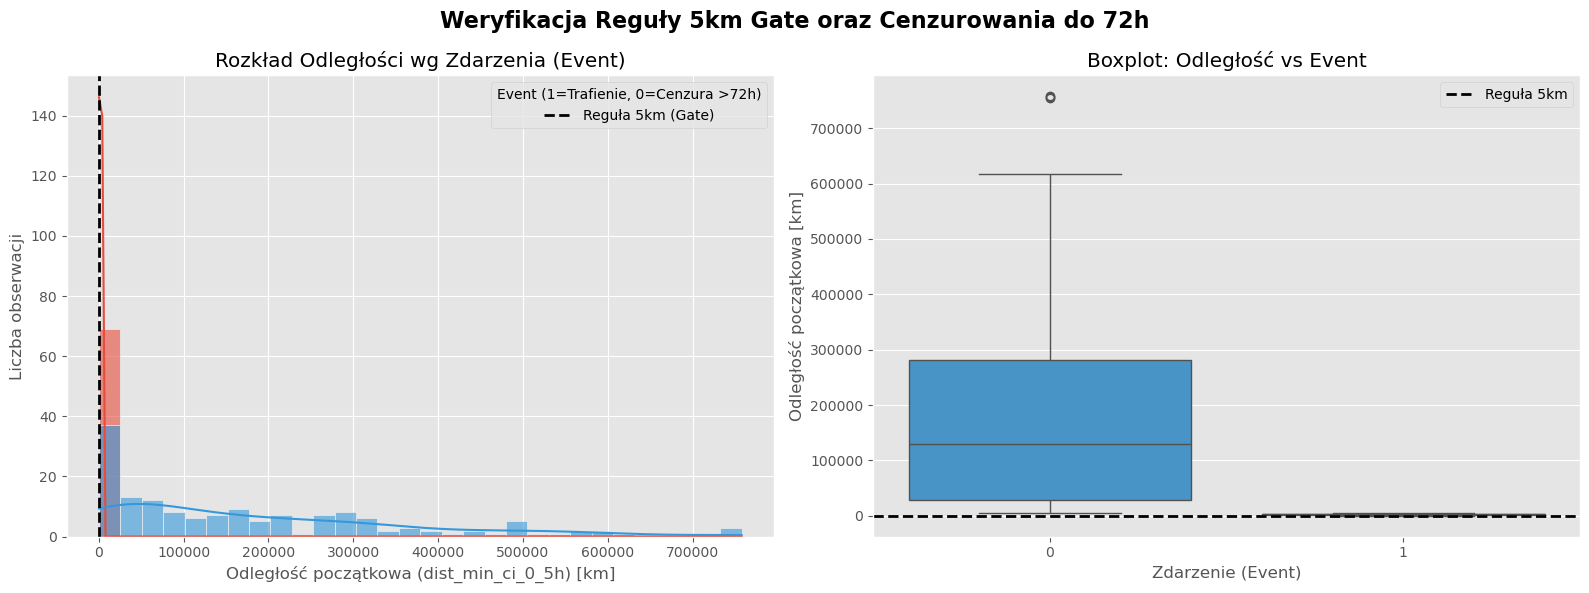

\n--- Statystyki trafień w zależności od strefy (5km Gate) ---


,Strefa (Zone),Wszystkie pożary,% Trafień (Event Rate),Liczba trafień (Event=1)
0,Daleko (>= 5km),221,31.22%,69


\nWniosek:
Zgodnie z naszymi obserwacjami, pożary poniżej 5km trafiają w cel niezwykle rzadko (lub w ogóle),
podczas gdy te bliższe niemal zawsze skutkują zdarzeniem (Event=1). To potwierdza sens
rozdzielenia modelowania na dwie niezależne strefy i budowę modeli zoptymalizowanych pod C-index oddzielnie!


In [4]:
# Tworzymy dodatkową zmienną dla celów EDA: czy pożar jest blisko (< 5km)
train_df['is_near_5km'] = train_df['dist_min_ci_0_5h'] < 5.0

# Inicjalizacja figury dla dwóch wykresów
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Weryfikacja Reguły 5km Gate oraz Cenzurowania do 72h', fontsize=16, fontweight='bold')

# --- Wykres 1: Rozkład (Histogram/KDE) ---
sns.histplot(
    data=train_df, 
    x='dist_min_ci_0_5h', 
    hue='event', 
    bins=30, 
    kde=True, 
    ax=axes[0], 
    palette=['#3498db', '#e74c3c'],
    alpha=0.6
)
axes[0].axvline(5.0, color='black', linestyle='--', linewidth=2, label='Reguła 5km (Gate)')
axes[0].set_title('Rozkład Odległości wg Zdarzenia (Event)')
axes[0].set_xlabel('Odległość początkowa (dist_min_ci_0_5h) [km]')
axes[0].set_ylabel('Liczba obserwacji')
axes[0].legend(title='Event (1=Trafienie, 0=Cenzura >72h)')

# --- Wykres 2: Boxplot ---
sns.boxplot(
    data=train_df, 
    x='event', 
    y='dist_min_ci_0_5h', 
    ax=axes[1], 
    palette=['#3498db', '#e74c3c']
)
axes[1].axhline(5.0, color='black', linestyle='--', linewidth=2, label='Reguła 5km')
axes[1].set_title('Boxplot: Odległość vs Event')
axes[1].set_xlabel('Zdarzenie (Event)')
axes[1].set_ylabel('Odległość początkowa [km]')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Tabela podsumowująca ---
print("\\n--- Statystyki trafień w zależności od strefy (5km Gate) ---")
summary = train_df.groupby('is_near_5km')['event'].agg(['count', 'mean', 'sum']).reset_index()
summary['is_near_5km'] = summary['is_near_5km'].map({False: 'Daleko (>= 5km)', True: 'Blisko (< 5km)'})
summary = summary.rename(columns={
    'is_near_5km': 'Strefa (Zone)',
    'count': 'Wszystkie pożary', 
    'mean': '% Trafień (Event Rate)', 
    'sum': 'Liczba trafień (Event=1)'
})
summary['% Trafień (Event Rate)'] = (summary['% Trafień (Event Rate)'] * 100).round(2).astype(str) + '%'
display(summary)

print("\\nWniosek:")
print("Zgodnie z naszymi obserwacjami, pożary poniżej 5km trafiają w cel niezwykle rzadko (lub w ogóle),")
print("podczas gdy te bliższe niemal zawsze skutkują zdarzeniem (Event=1). To potwierdza sens")
print("rozdzielenia modelowania na dwie niezależne strefy i budowę modeli zoptymalizowanych pod C-index oddzielnie!")

## Analiza Czasu do Zdarzenia (Time-to-Event) i Cenzurowania

W analizie przeżycia przewidujemy czas do wystąpienia zdarzenia. W tym zbiorze danych pożary są monitorowane do 72 godzin. Jeśli po 72 godzinach pożar nie uderzył w strefę ewakuacyjną, zdarzenie to jest **prawostronnie cenzurowane** (`event = 0`). 

W tej sekcji sprawdzimy:
1. Jak rozkłada się czas do uderzenia (dla `event = 1`).
2. Czy pożary zlokalizowane bliżej (< 5km) uderzają szybciej niż te, którym udaje się przedrzeć z dalszej odległości.

*(Uwaga: W poniższym kodzie zakładamy, że zmienna określająca czas to `time` lub `time_to_event`. Jeśli w głównym zbiorze nazywa się inaczej, np. `duration`, należy odpowiednio dostosować nazwę kolumny w zmiennej `TIME_COL`).*

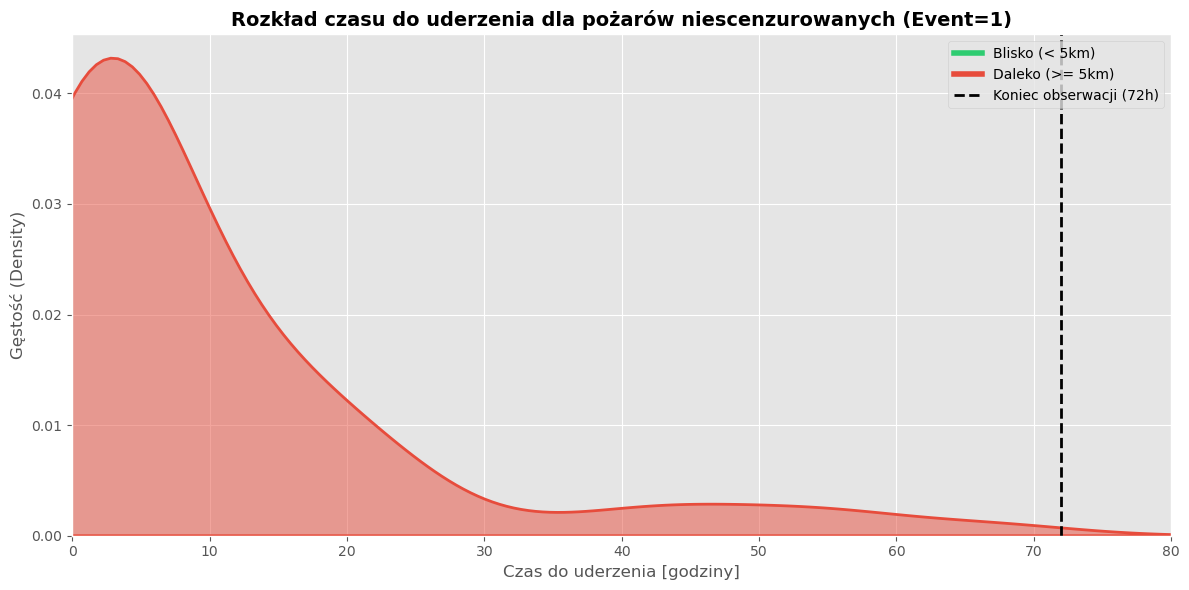

\n--- Średni czas do uderzenia wg strefy (tylko Event=1) ---


,count,mean,min,max,mediana
is_near_5km,,,,,
Daleko (>= 5km),69.0,9.96987,0.00122,66.920463,3.534846


In [6]:
# Zdefiniowanie nazwy kolumny czasu (dostosuj do zbioru, np. 'time', 'duration' lub 'time_to_hit')
# Zakładamy na potrzeby EDA, że nazywa się 'time'
TIME_COL = 'time_to_hit_hours' 

if TIME_COL in train_df.columns:
    # Filtrujemy tylko te przypadki, gdzie zdarzenie wystąpiło (brak cenzury w 72h)
    hits_only = train_df[train_df['event'] == 1].copy()
    
    plt.figure(figsize=(12, 6))
    
    # Rysujemy rozkład czasu do uderzenia, dzieląc na nasze strefy dystansowe
    sns.kdeplot(
        data=hits_only, 
        x=TIME_COL, 
        hue='is_near_5km', 
        fill=True, 
        common_norm=False, 
        palette=['#e74c3c', '#2ecc71'],
        alpha=0.5,
        linewidth=2
    )
    
    plt.axvline(72.0, color='black', linestyle='--', linewidth=2, label='Limit 72h (Cenzurowanie)')
    plt.title('Rozkład czasu do uderzenia dla pożarów niescenzurowanych (Event=1)', fontsize=14, fontweight='bold')
    plt.xlabel('Czas do uderzenia [godziny]', fontsize=12)
    plt.ylabel('Gęstość (Density)', fontsize=12)
    
    # Poprawa legendy
    handles = [plt.Line2D([0], [0], color='#2ecc71', lw=4),
               plt.Line2D([0], [0], color='#e74c3c', lw=4),
               plt.Line2D([0], [0], color='black', linestyle='--', lw=2)]
    plt.legend(handles, ['Blisko (< 5km)', 'Daleko (>= 5km)', 'Koniec obserwacji (72h)'], loc='upper right')
    
    plt.xlim(0, 80)
    plt.tight_layout()
    plt.show()
    
    # Krótkie podsumowanie statystyczne
    print(f"\\n--- Średni czas do uderzenia wg strefy (tylko Event=1) ---")
    display(hits_only.groupby('is_near_5km')[TIME_COL].describe()[['count', 'mean', 'min', 'max', '50%']].rename(
        index={False: 'Daleko (>= 5km)', True: 'Blisko (< 5km)'},
        columns={'50%': 'mediana'}
    ))
else:
    print(f"Kolumna czasu '{TIME_COL}' nie została znaleziona w zbiorze. Ustaw prawidłową nazwę.")

## Estymator Kaplana-Meiera: Prawdopodobieństwo Przeżycia w Czasie

Teraz wykorzystamy nieparametryczny estymator **Kaplana-Meiera**, aby zwizualizować krzywe przeżycia. "Przeżycie" w naszym kontekście oznacza, że pożar *jeszcze nie dotarł* do strefy ewakuacyjnej.

Podzielimy nasze dane na dwie grupy na podstawie odkrytej wcześniej reguły:
1. **Strefa "Blisko" (< 5km)**: Oczekujemy, że krzywa przeżycia drastycznie spadnie bardzo szybko (pożary szybko uderzają w cel).
2. **Strefa "Daleko" (>= 5km)**: Oczekujemy, że krzywa przeżycia pozostanie płaska i bliska 1.0, ponieważ większość z tych pożarów zostaje ugaszona lub omija strefę (są cenzurowane w 72h).

Wizualizacja ta wprost tłumaczy, dlaczego modele optymalizujące C-index tak bardzo zyskują na stratyfikacji odległości!

In [8]:
!pip install lifelines

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=712c81b486912e050f99370cfdec70db50c27a65fdfb4d55f1e849ecaadea7a8
  Stored in directory: C:\Users\Mateu\AppData\Local\Temp\pip-ephem-wheel-cache-uutzlf6i\wheels\a8\03\64\8557323821d25118c3a2dc1646996f7a962a8970d4b7d22473
Successfully built autograd-gamma


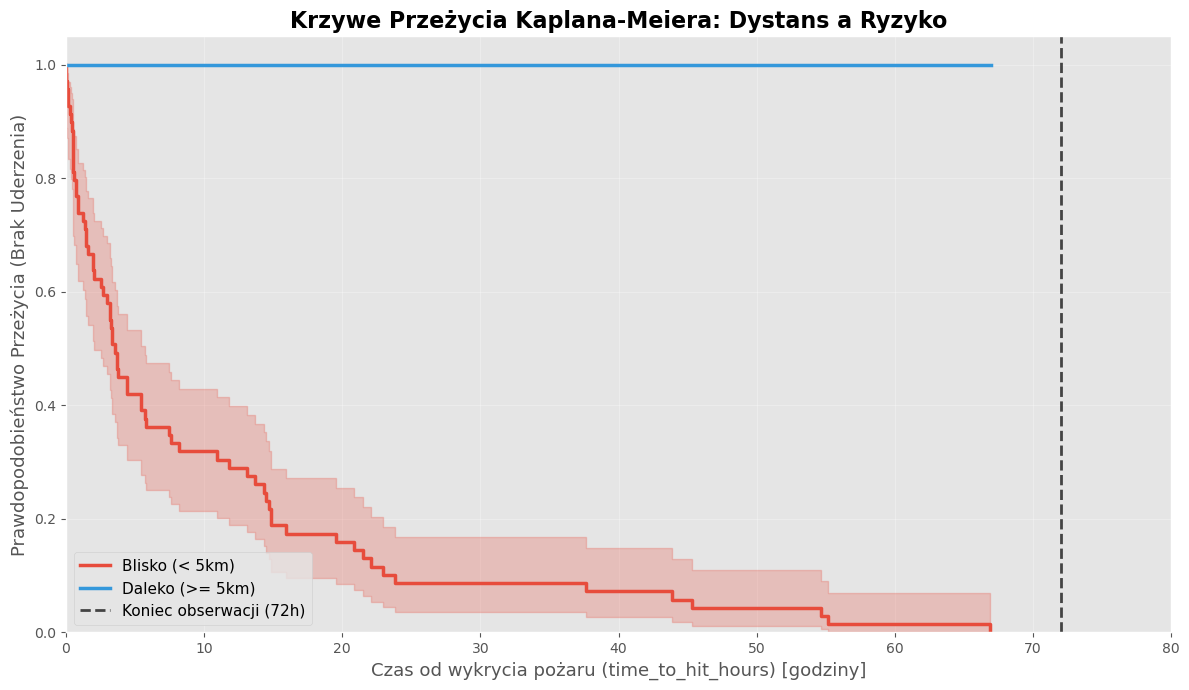

In [10]:
# Ustawiamy poprawną kolumnę czasu dla WiDS Datathon 2026
TIME_COL = 'time_to_hit_hours' 

# Jeśli nie jest zainstalowana, odkomentuj:
# !pip install lifelines

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd

if TIME_COL in train_df.columns:
    # Usuwamy ewentualne braki danych w używanych kolumnach, by uniknąć błędów biblioteki
    df_clean = train_df.dropna(subset=[TIME_COL, 'event', 'dist_min_ci_0_5h']).copy()
    
    # Tworzymy maski logiczne – pamiętając, że dystans jest w METRACH (5km = 5000m)
    mask_near = df_clean['dist_min_ci_0_5h'] < 5000.0
    mask_far = df_clean['dist_min_ci_0_5h'] >= 5000.0

    # Inicjalizacja estymatorów
    kmf_near = KaplanMeierFitter()
    kmf_far = KaplanMeierFitter()

    plt.figure(figsize=(12, 7))

    # 1. Dopasowanie i rysowanie dla strefy "Blisko" (< 5km)
    if mask_near.sum() > 0:
        kmf_near.fit(
            durations=df_clean.loc[mask_near, TIME_COL], 
            event_observed=df_clean.loc[mask_near, 'event'], 
            label='Blisko (< 5km)'
        )
        kmf_near.plot_survival_function(color='#e74c3c', linewidth=2.5, ci_show=True)

    # 2. Dopasowanie i rysowanie dla strefy "Daleko" (>= 5km)
    if mask_far.sum() > 0:
        kmf_far.fit(
            durations=df_clean.loc[mask_far, TIME_COL], 
            event_observed=df_clean.loc[mask_far, 'event'], 
            label='Daleko (>= 5km)'
        )
        kmf_far.plot_survival_function(color='#3498db', linewidth=2.5, ci_show=True)

    # Oznaczenie limitu cenzurowania do 72 godzin
    plt.axvline(72.0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Koniec obserwacji (72h)')

    # Upiększanie wykresu
    plt.title('Krzywe Przeżycia Kaplana-Meiera: Dystans a Ryzyko', fontsize=16, fontweight='bold')
    plt.xlabel('Czas od wykrycia pożaru (time_to_hit_hours) [godziny]', fontsize=13)
    plt.ylabel('Prawdopodobieństwo Przeżycia (Brak Uderzenia)', fontsize=13)
    plt.ylim(0, 1.05)
    plt.xlim(0, 80)
    plt.legend(loc='lower left', fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Błąd: Kolumna czasu '{TIME_COL}' nie znajduje się w zbiorze danych. Sprawdź dostępne kolumny: {train_df.columns.tolist()}")